In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/gene_expression.csv')

In [3]:
X = df.drop('Cancer Present', axis=1)
y = df['Cancer Present']

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.tree import DecisionTreeClassifier

In [7]:
model = DecisionTreeClassifier()

In [8]:
params = {
    'criterion':["gini", "entropy", "log_loss"],
    'splitter': ['best', 'random'],
    'max_depth':[4, 6, 8, 10, 12]
}

In [9]:
final_model = GridSearchCV(model, params, cv=3,verbose=2)

In [10]:
final_model.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .........criterion=gini, max_depth=6, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=6, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=6, splitter=best; total time=   0.0s
[CV] END .......criterion=gini, max_depth=6, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=6, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=6, spl

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [4, 6, ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [13]:
final_tree = final_model.best_estimator_

In [12]:
final_model.best_params_

{'criterion': 'gini', 'max_depth': 6, 'splitter': 'best'}

In [14]:
from sklearn.tree import plot_tree

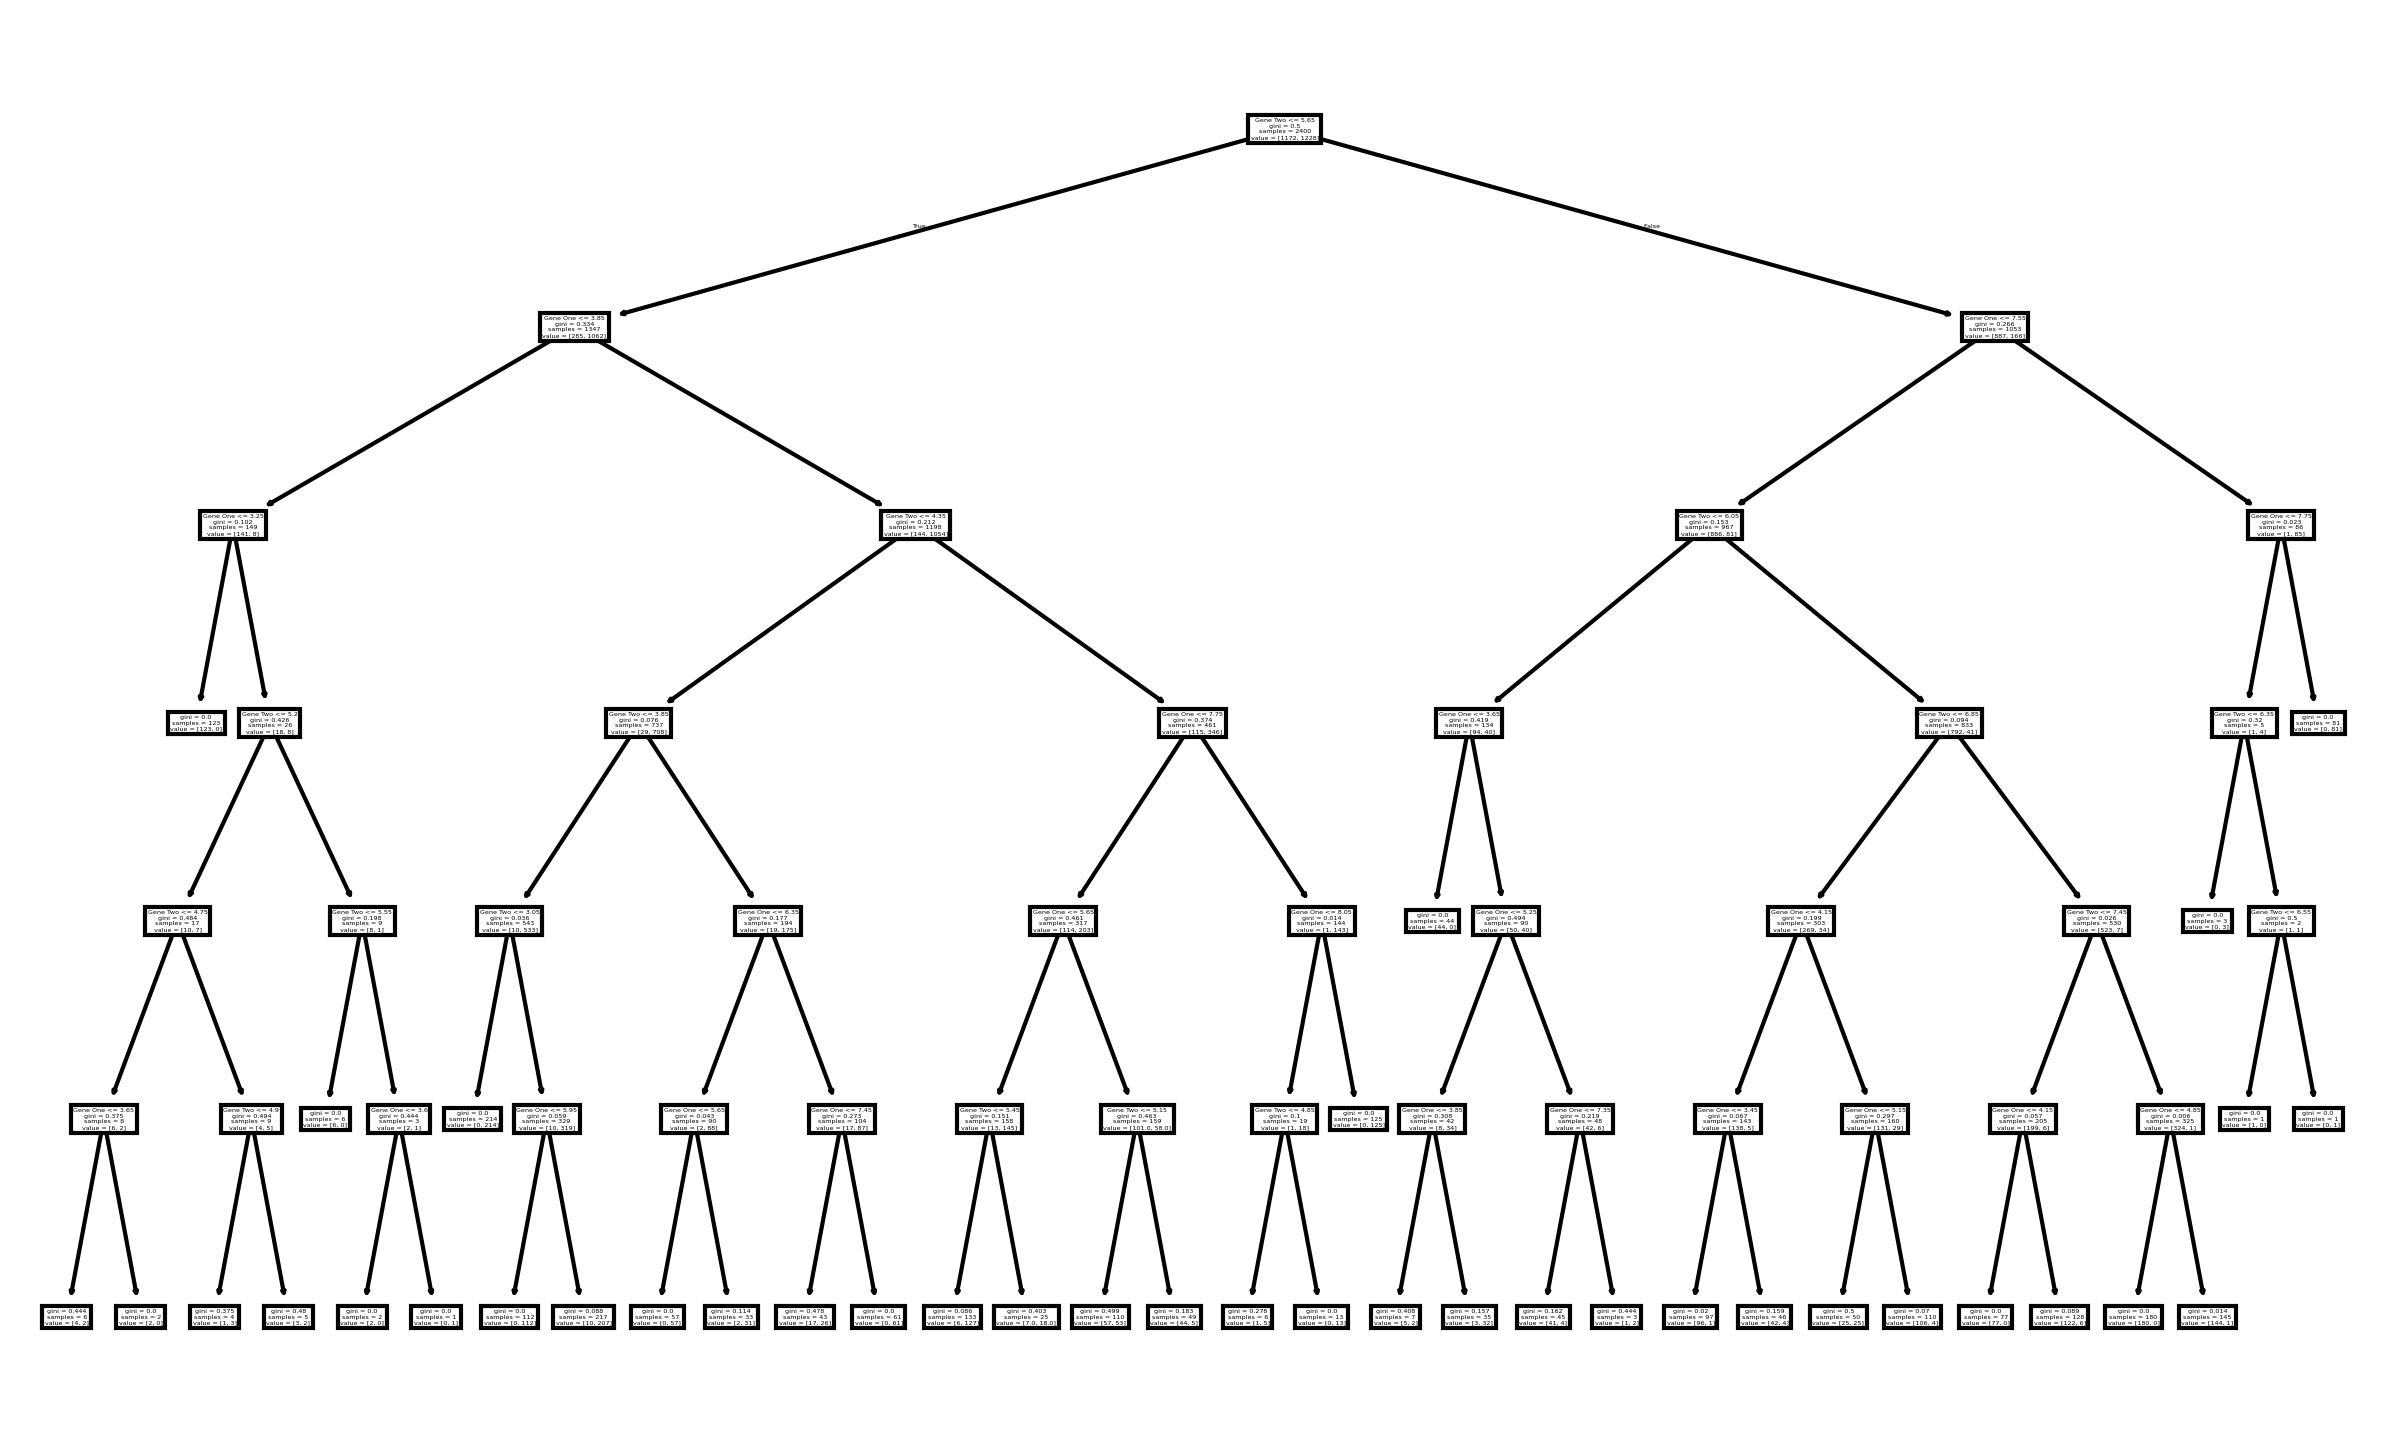

In [15]:
plt.figure(figsize=(10, 6), dpi=300)
plot_tree(final_tree, feature_names=X.columns)
plt.show()

In [16]:
y_pred = final_model.predict(X_test)

In [17]:
from sklearn.metrics import classification_report

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       328
           1       0.96      0.89      0.92       272

    accuracy                           0.93       600
   macro avg       0.94      0.93      0.93       600
weighted avg       0.93      0.93      0.93       600

